<a href="https://colab.research.google.com/github/RAseng77/computer_vision_study/blob/main/%EC%BB%B4%ED%93%A8%ED%84%B0%EA%B8%B0%EB%B3%B8_%EA%B8%B0%EC%B4%88/AI%EC%82%AC%EC%A7%84%EB%B6%84%EB%A5%98(%EC%8B%A4%EC%8A%B5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# numpy 1.x + imgaug 설치
!pip uninstall -y numpy imgaug
!pip install "numpy<2.0" "imgaug==0.4.0"

# 런타임 재시작 필요 (중요!)
import os, signal
os.kill(os.getpid(), signal.SIGKILL)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!unzip "/content/drive/MyDrive/file/강아지_고양이 vs AI 강아지_고양이 분류.zip" -d "/content/강아지_고양이_vs_AI"

Archive:  /content/drive/MyDrive/file/강아지_고양이 vs AI 강아지_고양이 분류.zip
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/235.jpeg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1915.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1911.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/234.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1906.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1920.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/231.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1917.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1919.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1912.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/222.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1905.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/239.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/real/1904.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/236.jpg  
  inflating: /content/강아지_고양이_vs_AI/7/test/ai/232.jpeg  
  inflat

In [3]:
!ls "/content/강아지_고양이_vs_AI/7"

test  train  val


In [4]:
import os
import glob
import random
import tqdm
import numpy as np
import matplotlib.pyplot as plt

# 이미지 처리
from PIL import Image # 이미지 로드/ 저장 및 조작

# PyTorch 기본
import torch          # PyTorch 메인 라이브러리
import torch.nn as nn # 신경망 레이어/ 모듈 정의 (Linear, Conv2d 등)
import torch.optim as optim # 최적화 알고리즘 (SGD, Adam 등)

# PyTorch 데이터 관련
from torch.utils.data import DataLoader, Dataset
# Dataset: 커스텀 데이터셋 정의 클래스
# DataLoader: 배치 단위로 데이터 로딩 (shuffle, 병렬 로딩 지원)

# Torchvision (이미지 전처리/모델)
from torchvision.utils import make_grid
# 여러 이미지를 격자로 붙여서 시각화

from torchvision.datasets import ImageFolder
# 폴더 구조로 정리된 이미지 데이터셋 로드 (ex: class별 하위 폴더)

import torchvision.transforms as transforms
# 데이터 전처리/증강 (Resize, ToTensor, Normalize, Flip 등)

import torchvision.models as models
# ResNet, VGG, EfficientNet 등 사전학습 모델 불러오기

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [6]:
device

device(type='cuda')

In [7]:
print('Device: ', device)

Device:  cuda


In [8]:
# 여러 이미지를 한 줄에 나란히 출력하는 함수
def display_images(image_paths, title, max_images=4):
  """
  지정된 경로의 이미지를 최대 max_images(기본 4개)까지 출력합니다.

  Args:
      image_paths (list): 출력할 이미지 파일들의 경로 리스트
      title (str): 각 이미지 위에 공통적으로 표시할 제목
      max_images (int): 최대 출력할 이미지 개수 (기본값=4)
  """
  # 전체 figure 크기 지정 (가로 12인치, 세로 3인치)
  plt.figure(figsize=(12, 3))

  # image_path에서 최대 max_images 개수만큼 반복
  for i, image_path in enumerate(image_paths[:max_images]):
    # 이미지 읽기 (numpy 배열 형태로 반환됨)
    img = plt.imread(image_path)

    # subplot 생성
    plt.subplot(1, max_images, i+1)

    # 이미지 출력
    plt.imshow(img)

    plt.title(title)
    plt.axis('off')

  plt.show()


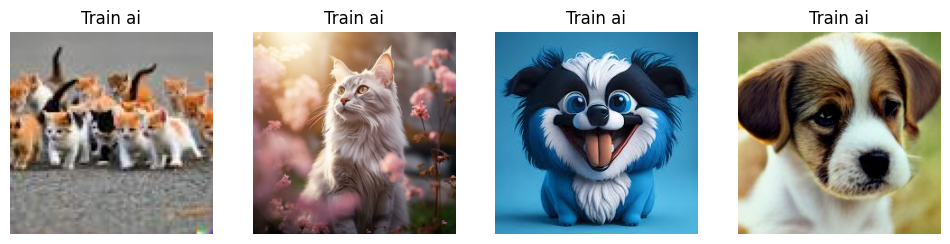

Train ai 총 이미지 수: 1067


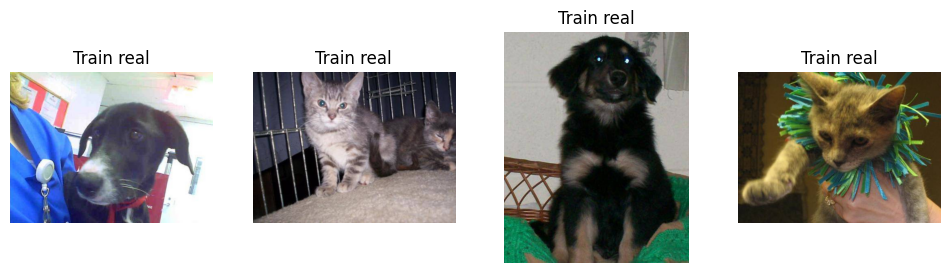

Train real 총 이미지 수: 1501


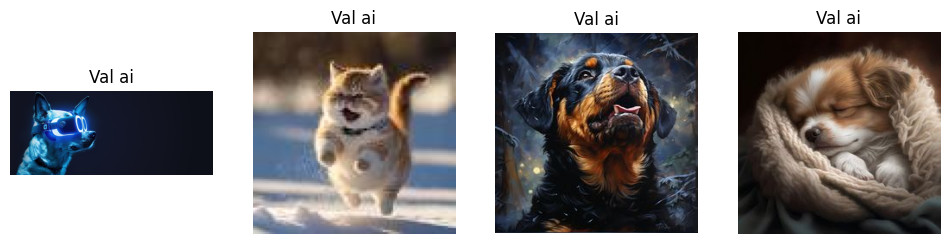

Val ai 총 이미지 수: 221


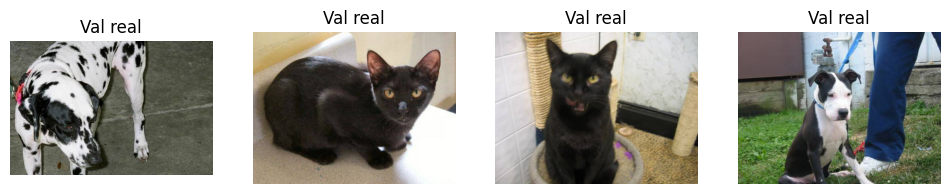

Val real 총 이미지 수: 261


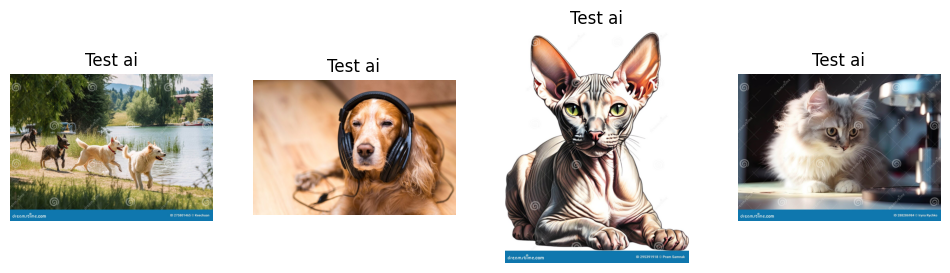

Test ai 총 이미지 수: 20


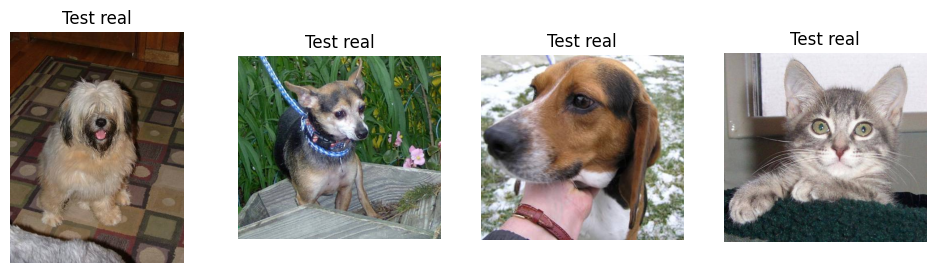

Test real 총 이미지 수: 20


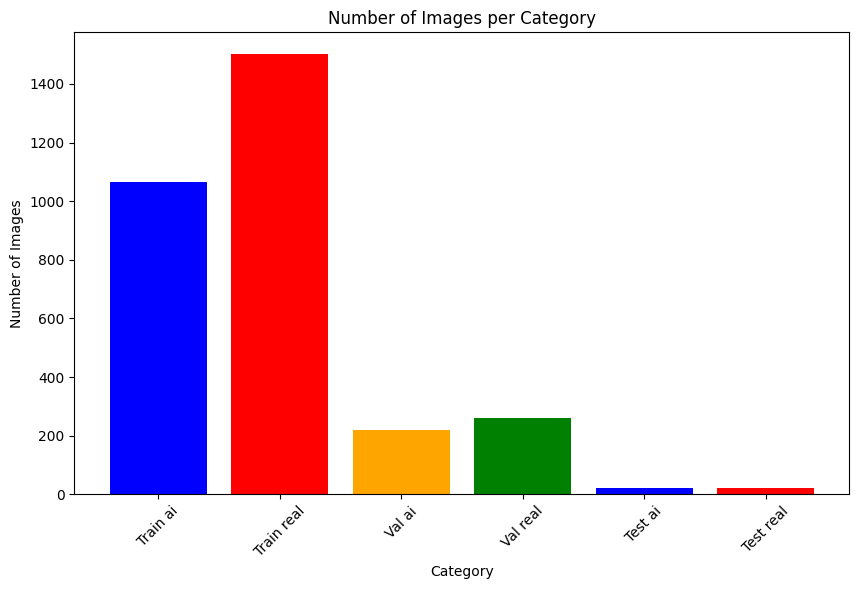

In [9]:
# 이미지와 바 그래프 출력
categories = ['Train ai', 'Train real', 'Val ai', 'Val real', 'Test ai', 'Test real']

for category in categories:
  image_paths = glob.glob(f'/content/강아지_고양이_vs_AI/7/{category.lower().replace(" ", "/")}/*')
  display_images(image_paths, category)
  print(f'{category} 총 이미지 수: {len(image_paths)}')

# 바 그래프 생성
plt.figure(figsize=(10, 6))
plt.bar(categories, [len(glob.glob(f'/content/강아지_고양이_vs_AI/7/{category.lower().replace(" ","/")}/*')) for category in categories], color = ['blue', 'red', 'orange', 'green'])
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Number of Images per Category')
plt.xticks(rotation=45)
plt.show()

In [10]:
from imgaug import augmenters as iaa # imgaug의 증강기법 모듈 불러오기
import imgaug as ia # imgaug 라이브러리 전체 불러오기

# imgaug를 활용한 데이터 증강 클래스 정의
class ImgAugTransform:
  def __init__(self):
    # 여러 증강 기법을 순차적으로 적용하기 위해 Sequential 정의
    self.aug = iaa.Sequential([
        iaa.Fliplr(0.5), # 이미지를 50% 확률로 좌우 반전
        iaa.Affine(rotate=(-20, 20), mode='symmetric'),
        # Affin 변환: -20 ~ +20도 범위에서 랜덤 회전
        # model='symmertric' -> 회전 후 생기는 빈 공간은 대칭 반사로 채움
    ])


  def __call__(self, img):
    # PIL Image -> numpy 배열로 변환 (imgaug는 numpy 형식 입력 필요)
    img = np.array(img)

    # 정의한 증강(aug)을 적용한 후, 증강된 이미지를 반환
    return self.aug.augment_image(img)

In [11]:
# 커스텀 데이터셋 클래스 정의 (ImageFolder 상속)
class CustomDataset(ImageFolder):
  def __init__(self, root, imgaug=None, transform=None, sample_per_class=None):
    """
    Args:
        root (str): 데이터셋 루트 경로
        imgaug: imgaug 증강 함수
        transform: torchvision.transform
        sample_per_class: 클래스별 사용할 최대 샘플 수
    """
    super(CustomDataset, self).__init__(root, transform=transform)

    # imgaug 변환기를 저장 (있으면 __getitem__에서 적용됨)
    self.imgaug_transform = imgaug

    # 클래스별 샘플 수 제한 (언더 샘플링)
    if sample_per_class is not None:
      self.samples = self._reduce_samples(sample_per_class)

  def _reduce_samples(self, sample_per_class):
    """
    클래스별로 sample_per_class 개수만큼 샘플을 유지하고 나머지는 버림.
    """
    class_samples = {}

    # self.samples = [(경로, 라벨), ...]
    for path, target in self.samples:
      if target not in class_samples:
        class_samples[target] = [path] # 새 클래스 시작
      else:
        class_samples[target].append(path)


    reduced_samples = []
    for target, paths in class_samples.items():
      if len(paths) > sample_per_class:
        # 샘플 수가 많으면 랜덤하게 sample_per_class개 선택
        reduced_samples.extend([(path, target) for path in random.sample(paths, sample_per_class)])
      else:
        # 샘플 수가 적으면 그대로 사용
        reduced_samples.extend([(path, target) for path in paths])

    return reduced_samples

  def __getitem__(self, index):
    """
    index번째 샘플을 불러오고, imgaug -> transform 순서로 변환 적용.
    """
    path, target = self.samples[index]
    img = self.loader(path) # PIL Image 로드

    # imgaug 증강 적용 (numpy 배열 반환)
    if self.imgaug_transform is not None:
      img = self.imgaug_transform(img)
      img = Image.fromarray(img) # 다시 PIL Image 변환

    # torchvision 변환 적용
    if self.transform is not None:
      img = self.transform(img)

    return img, target # 최종 (Tensor 이미지 ,라벨) 반

In [12]:
# PyTorch transforms에서 ToTensor 및 Normalize만 적용
from torchvision import transforms
pytorch_transforms = transforms.Compose([
    transforms.Resize((224, 224)), # 이미지 크기 조절
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

In [13]:
# 데이터셋 및 데이터 로더 초기화
train_dataset = CustomDataset('/content/강아지_고양이_vs_AI/7/train', imgaug=ImgAugTransform(), transform=pytorch_transforms)
val_dataset = CustomDataset('/content/강아지_고양이_vs_AI/7/val', imgaug=None, transform=pytorch_transforms, sample_per_class=64)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=64, shuffle=False)

In [14]:
# DataLoader에서 샘플을 이미지를 load해 show하는 함수
def imshow(img, labels, class_to_idx, size=(20, 20), mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)):
  # class_to_idx: {"강아지": 0, "고양이": 1} 형태의 매핑
  # idx_to_class: {0: "강아지", 1: "고양이"} 형태로 변환
  idx_to_class = {v:k for k ,v in class_to_idx.items()}

  # (C, H, W) 텐서를 (H, W, C)로 변환
  img = img.numpy().transpose((1,2,0))

  # 역정규화를 위해 mean, std를 numpy 배열로 변환
  mean = np.array(mean)
  std = np.array(std)

  # 정규화 해제: (x * std + mean)
  img = img * std + mean
  # 픽셀 값 범위를 [0,1]로 제한 (시각화 깨짐 방지)
  img = np.clip(img, 0,1)

  plt.figure(figsize=size)
  plt.imshow(img)
  plt.axis('off')

  # 이미지 위에 레이블 번호와 실제 클래스 이름 출력
  for i, label in enumerate(labels[:8]):  # 첫 8개 레이블까지만 표시
      class_name = idx_to_class[label.item()]   # 정수 라벨 → 클래스 이름 변환
      # 4열 기준으로 x, y 좌표를 계산해 텍스트 위치 설정
      x = (i % 4) * (img.shape[1] // 4) + 100  # 열 단위 위치
      y = (i // 4) * (img.shape[0] // 2) + 10  # 행 단위 위치
      # 라벨 번호 + 클래스 이름 출력
      plt.text(x, y, f'{label.item()}, {class_name}', color='black', fontsize=14)

    # 최종 출력
  plt.show()

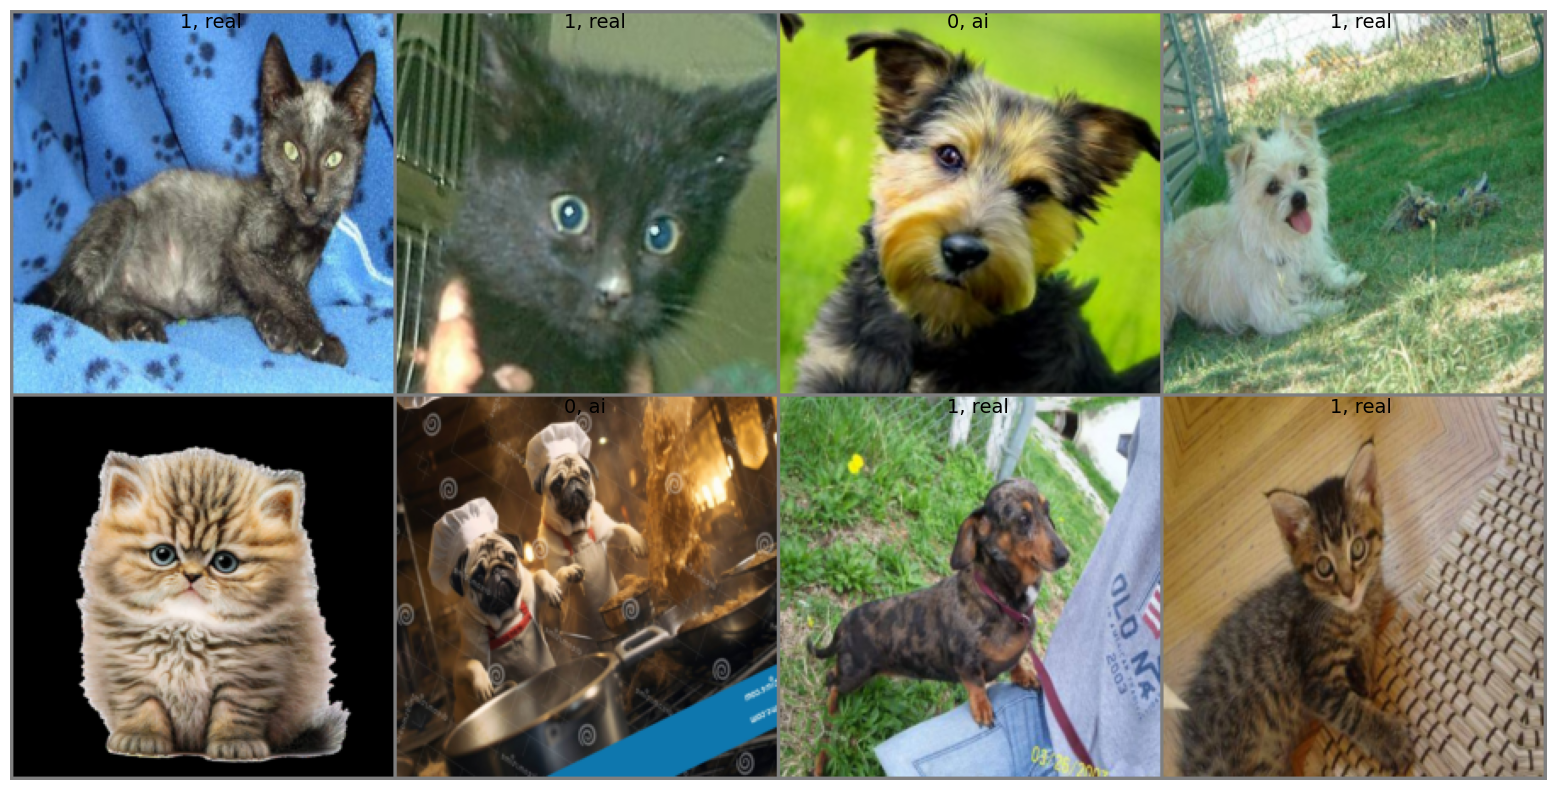

In [15]:
# DataLoader를 이용하여 배치 데이터 가져오기
dataiter = iter(train_loader)
images, label = next(dataiter)

# 이미지 그리드 생성 및 시각화, nrow를 조정하여 한 줄에 표시되는 이미지의 수 조정
class_to_idx = train_loader.dataset.class_to_idx # DataLoader에서 class_to_idx 매핑 가져오기

imshow(make_grid(images[:8], nrow=4), label, class_to_idx, size=(20,10))

In [16]:
# Alexnet 모델 로드 및 네트워크 구조 확인
alexnet = models.alexnet(pretrained=True)

# 모델의 모든 파라미터를 고정
for param in alexnet.parameters():
  param.requires_grad = False

# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
alexnet.classifier[6] = nn.Linear(4096, 1)
alexnet.classifier[6].requires_grad = True

alexnet = alexnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 172MB/s]


In [17]:
# 손실 함수
criterion = nn.BCEWithLogitsLoss()

In [18]:
def validate_model(net, val_loader, criterion):
  net.eval() # 모델을 평가 모드로 설정 (Dropout, BatchNorm 등이 평가 모드 동작)

  val_loss = 0.0 # 검증 데이터셋 전체 손실값 누적
  correct = 0 # 올바르게 예측한 개수
  total = 0 # 전체 샘플 수

  with torch.no_grad(): # 평가할 때는 기울기 계산 x (메모리 절약, 속도 향상)
    for inputs, labels in val_loader: # 배치 단위로 검증 데이터 로드
      # 데이터를 device(GPU/CPU)로 이동
      inputs, labels = inputs.to(device), labels.to(device)

      # 이진 분류라면 레이블 형태를 (batch_size, 1)로 맞추고 float으로 변환
      labels = labels.float().unsqueeze(1)

      # 모델 예측
      outputs = net(inputs)

      # 손실 계산 (batch 단위)
      val_loss += criterion(outputs, labels).item()

      # sigmoid로 확률값 변환 후, 0.5 이상이면 True(=1), 미만이면 False(=0)
      predicted = torch.sigmoid(outputs) > 0.5

      # 배치 크기만큼 샘플 수 누적
      total += labels.size(0)

      # 예측 결과와 실제 라벨 비교 -> 맞춘 개수 누적
      correct += (predicted == labels).sum().item()

  # 전체 배치 평균 손실
  val_loss /= len(val_loader)

  # 전체 정확도(%) 계산
  val_accuracy = 100 * correct / total

  return val_loss, val_accuracy


In [19]:
import torch.optim as optim

def train_model(optimizer_name, net, train_loader, val_loader, criterion, num_epochs=10):
  # optimizer설정
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(net.parameters(), lr=0.00003, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = optim.Adam(net.parameters(), lr=0.00003, betas=(0.9, 0.999))
    elif optimizer_name == 'RAdam':
        optimizer = optim.RAdam(net.parameters(), lr=0.00003, betas=(0.9, 0.999))
    else:
        raise ValueError(f"Unsupported optimizer: {optimizer_name}")

    # 학습/검증 손실과 검증 정확도를 저장할 리스트
    train_losses = []
    val_losses = []
    val_accuracies = []


    for epoch in range(num_epochs):
      net.train() # 학습 모드 (Dropout/BatchNorm 등 학습 동작)
      running_loss = 0.0
      for inputs, labels in train_loader:
        # 배치를 디바이스로 이동
        inputs, labels = inputs.to(device), labels.to(device)

        # 이진 분류(BCE류)면 보통 (N,) 라벨을 (N,1) float로 바꿔줌
        labels = labels.float().unsqueeze(1)

        # 이전 step의 그래디언트 초기화
        optimizer.zero_grad()

        # forward
        outputs = net(inputs)

        # loss 계산
        loss = criterion(outputs, labels)

        # backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적 (배치 평균 손실)
        running_loss += loss.item()

      # 매 에포크마다 평균 학습 손실 계산
      train_loss = running_loss / len(train_loader)
      train_losses.append(train_loss)

      # 검증 손실 및 정확도 계산
      val_loss, val_accuracy = validate_model(net, val_loader, criterion)
      val_losses.append(val_loss)
      val_accuracies.append(val_accuracy)

      print(f'[{optimizer_name}] Epoch {epoch + 1}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}, Validation Accuracy: {val_accuracy:.2f}%')


    return train_losses, val_losses, val_accuracies

In [20]:
train_losses_alexnet, val_losses_alexnet, val_accuracies_alexnet = train_model('RAdam', alexnet, train_loader, val_loader, criterion)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[RAdam] Epoch 1, Train Loss: 0.766853, Val Loss: 0.726081, Validation Accuracy: 49.22%
[RAdam] Epoch 2, Train Loss: 0.745106, Val Loss: 0.700453, Validation Accuracy: 53.91%
[RAdam] Epoch 3, Train Loss: 0.707472, Val Loss: 0.670962, Validation Accuracy: 59.38%
[RAdam] Epoch 4, Train Loss: 0.667910, Val Loss: 0.640068, Validation Accuracy: 59.38%
[RAdam] Epoch 5, Train Loss: 0.631270, Val Loss: 0.608826, Validation Accuracy: 67.19%
[RAdam] Epoch 6, Train Loss: 0.598762, Val Loss: 0.578370, Validation Accuracy: 71.88%
[RAdam] Epoch 7, Train Loss: 0.570170, Val Loss: 0.549114, Validation Accuracy: 73.44%
[RAdam] Epoch 8, Train Loss: 0.538063, Val Loss: 0.521499, Validation Accuracy: 75.00%
[RAdam] Epoch 9, Train Loss: 0.509599, Val Loss: 0.495542, Validation Accuracy: 78.12%
[RAdam] Epoch 10, Train Loss: 0.489867, Val Loss: 0.472026, Validation Accuracy: 79.69%


In [21]:
# VGG 모델 로드 및 네트워크 구조 확인
vgg = models.vgg19(pretrained=True)

# 모델의 모든 파라미터를 고정
for param in vgg.parameters():
    param.requires_grad = False

# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
vgg.classifier[6] = nn.Linear(4096, 1)
vgg.classifier[6].requires_grad = True

vgg = vgg.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:06<00:00, 84.7MB/s]


In [22]:
train_losses_vgg, val_losses_vgg, val_accuracies_vgg = train_model('RAdam', vgg, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.688803, Val Loss: 0.700840, Validation Accuracy: 51.56%
[RAdam] Epoch 2, Train Loss: 0.674603, Val Loss: 0.688835, Validation Accuracy: 53.91%
[RAdam] Epoch 3, Train Loss: 0.676429, Val Loss: 0.674155, Validation Accuracy: 57.03%
[RAdam] Epoch 4, Train Loss: 0.659873, Val Loss: 0.656891, Validation Accuracy: 60.16%
[RAdam] Epoch 5, Train Loss: 0.624357, Val Loss: 0.638907, Validation Accuracy: 63.28%
[RAdam] Epoch 6, Train Loss: 0.616784, Val Loss: 0.620448, Validation Accuracy: 67.97%
[RAdam] Epoch 7, Train Loss: 0.588834, Val Loss: 0.601491, Validation Accuracy: 71.09%
[RAdam] Epoch 8, Train Loss: 0.576653, Val Loss: 0.583546, Validation Accuracy: 76.56%
[RAdam] Epoch 9, Train Loss: 0.555764, Val Loss: 0.565295, Validation Accuracy: 78.12%
[RAdam] Epoch 10, Train Loss: 0.535291, Val Loss: 0.548062, Validation Accuracy: 79.69%


In [23]:
# Resnet 모델 로드 및 네트워크 구조 확인
resnet = models.resnet50(pretrained=True)

# 모델의 모든 파라미터를 고정
for param in resnet.parameters():
  param.requires_grad = False

# classifier의 마지막 레이어를 Binary Classification Task에 맞게 교체하고, 이 레이어의 파라미터는 학습 가능하도록 설정
resnet.fc = nn.Linear(2048, 1)
resnet.fc.requires_grad = True

resnet = resnet.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 198MB/s]


In [24]:
train_losses_resnet, val_losses_resnet, val_accuracies_resnet = train_model('RAdam', resnet, train_loader, val_loader, criterion)

[RAdam] Epoch 1, Train Loss: 0.684848, Val Loss: 0.714318, Validation Accuracy: 50.78%
[RAdam] Epoch 2, Train Loss: 0.678852, Val Loss: 0.708193, Validation Accuracy: 51.56%
[RAdam] Epoch 3, Train Loss: 0.674915, Val Loss: 0.698792, Validation Accuracy: 53.12%
[RAdam] Epoch 4, Train Loss: 0.661783, Val Loss: 0.691252, Validation Accuracy: 55.47%
[RAdam] Epoch 5, Train Loss: 0.651415, Val Loss: 0.678178, Validation Accuracy: 56.25%
[RAdam] Epoch 6, Train Loss: 0.642337, Val Loss: 0.666874, Validation Accuracy: 58.59%
[RAdam] Epoch 7, Train Loss: 0.628479, Val Loss: 0.654053, Validation Accuracy: 58.59%
[RAdam] Epoch 8, Train Loss: 0.616278, Val Loss: 0.637188, Validation Accuracy: 63.28%
[RAdam] Epoch 9, Train Loss: 0.606021, Val Loss: 0.628200, Validation Accuracy: 62.50%
[RAdam] Epoch 10, Train Loss: 0.593601, Val Loss: 0.611322, Validation Accuracy: 71.09%


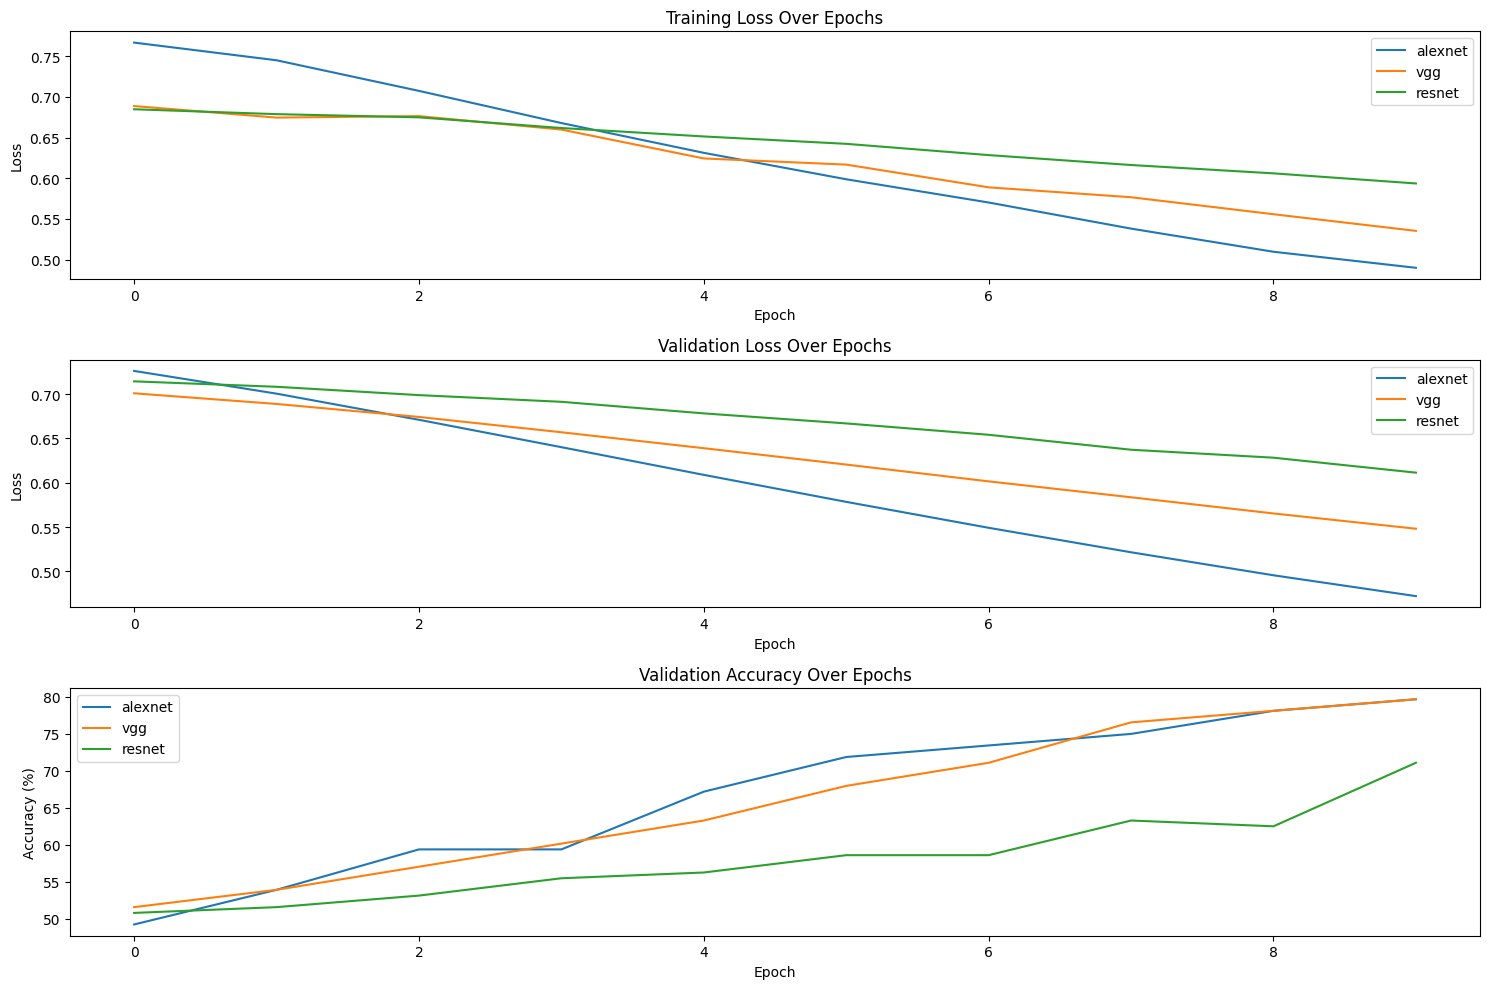

In [25]:
# 학습 손실과 검증 정확도 그래프 그리기
plt.figure(figsize=(15, 10))

# 학습 손실 그래프
plt.subplot(3, 1, 1)  # 3행 1열의 첫 번째 위치
plt.plot(train_losses_alexnet, label='alexnet')
plt.plot(train_losses_vgg, label='vgg')
plt.plot(train_losses_resnet, label='resnet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()

# 검증 손실 그래프
plt.subplot(3, 1, 2)  # 3행 1열의 두 번째 위치
plt.plot(val_losses_alexnet, label='alexnet')
plt.plot(val_losses_vgg, label='vgg')
plt.plot(val_losses_resnet, label='resnet')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss Over Epochs')
plt.legend()

# 검증 정확도 그래프
plt.subplot(3, 1, 3)  # 3행 1열의 세 번째 위치
plt.plot(val_accuracies_alexnet, label='alexnet')
plt.plot(val_accuracies_vgg, label='vgg')
plt.plot(val_accuracies_resnet, label='resnet')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Validation Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
# Image load 및 tensor로 변환
def load_and_transform_image(image_path, transform):
  # 이미지 파일 열기
  # 항상 RGB 모드로 변환 (흑백/투명 채널이 있어도 일관성 있게 3채널 맞춤)
  image = Image.open(image_path).convert('RGB')
  return transform(image).unsqueeze(0).to(device)  # 이미지를 모델에 맞게 변환하고 배치 차원 추가

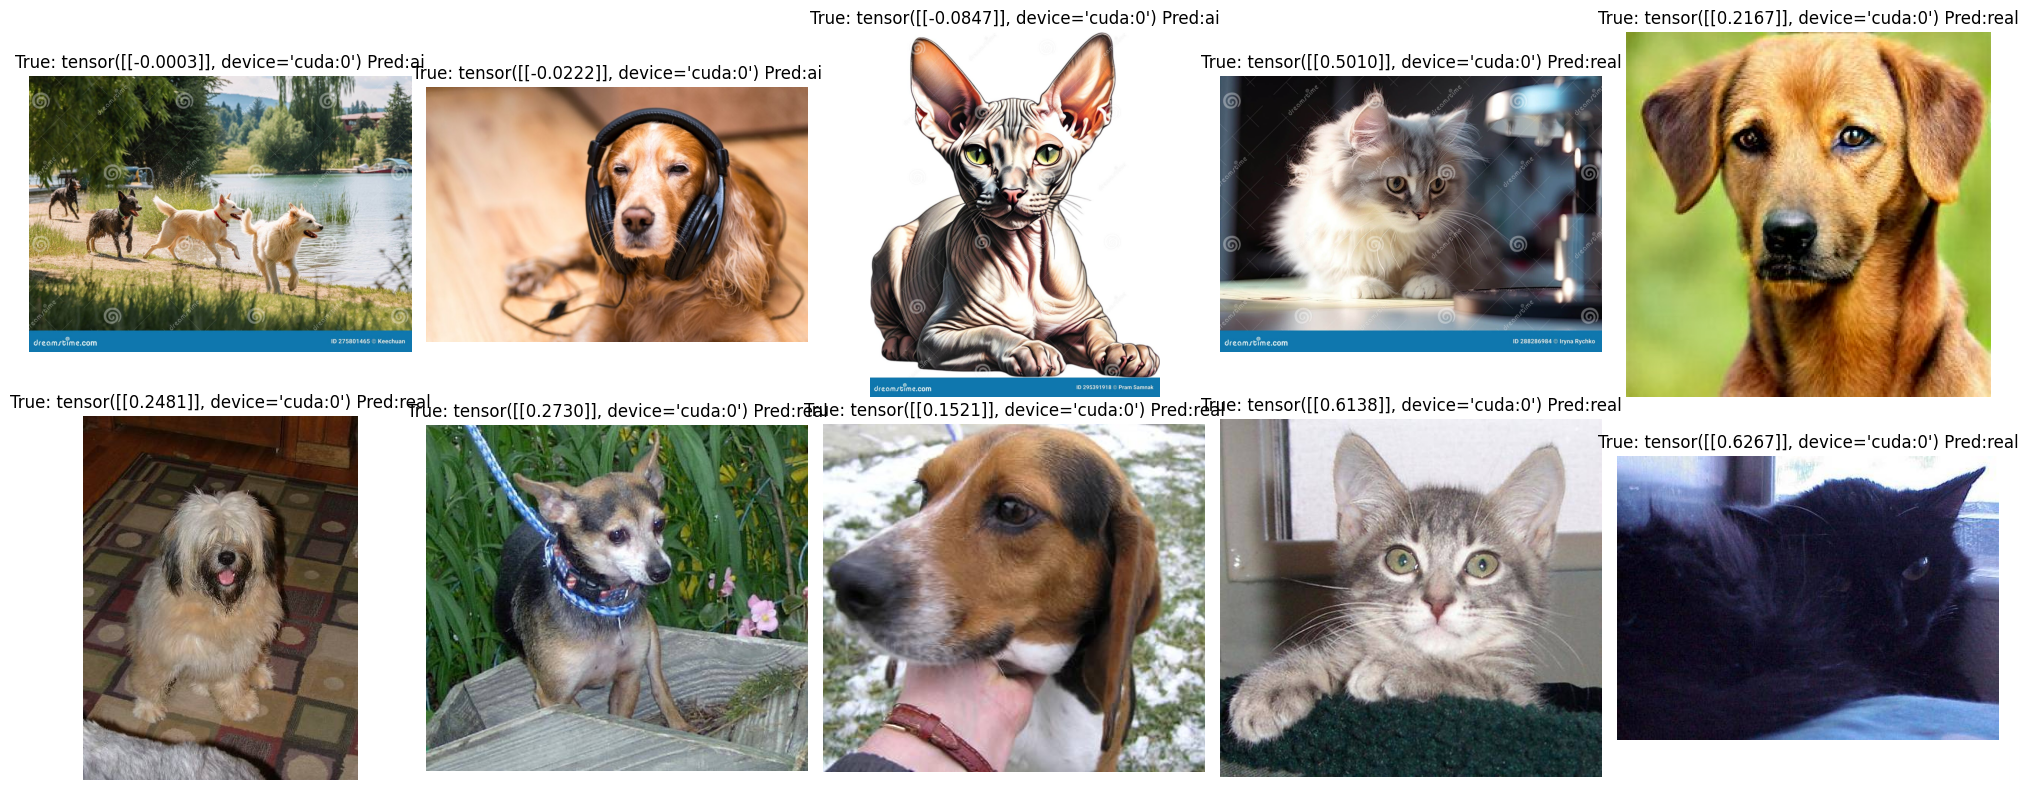

In [27]:
class_folders = {
    'ai': '/content/강아지_고양이_vs_AI/7/test/ai',
    'real':'/content/강아지_고양이_vs_AI/7/test/real'
}

plt.figure(figsize=(20, 8)) # 전체 출력 영역 크기 설정
counter = 1

# 각 클래스별로 5장의 이미지 추론 및 시각화
for class_name, folder_path in class_folders.items():
  # 해당 클래스의 이미지 경로 가져오기
  image_paths = glob.glob(os.path.join(folder_path, '*'))
  selected_paths = image_paths[:5]

  for image_path in selected_paths:
    image = load_and_transform_image(image_path, pytorch_transforms)

    resnet.eval() # 모델을 평가모드로 설정
    # 모델을 사용한 추론
    with torch.no_grad():
      outputs = resnet(image)
      # 시그모이드 함수 적용하여 확률 얻기
      probs = torch.sigmoid(outputs).item()
      prediction = 'real' if probs >= 0.5 else 'ai'

    # 결과 시각화
    plt.subplot(2, 5, counter)
    plt.imshow(Image.open(image_path))
    plt.title(f'True: {outputs} Pred:{prediction}')
    plt.axis('off')

    counter += 1

plt.tight_layout()
plt.show()

In [28]:
# 평가 지표 계산에 필요한 함수 불러오기
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def evaluate_model(model, class_folders, transform):
    # 모델을 평가 모드로 전환 (Dropout, BatchNorm 등 비활성화)
    model.eval()
    # 모델을 GPU나 CPU로 이동 (device 변수는 사전에 정의되어 있어야 함)
    model.to(device)

    all_preds = []   # 예측 결과 저장용 리스트
    all_labels = []  # 실제 라벨 저장용 리스트

    # class_folders: { 'real': '경로1', 'fake': '경로2' } 형태의 딕셔너리
    for class_name, folder_path in class_folders.items():
        # 해당 클래스 폴더 안의 모든 이미지 파일 경로 불러오기
        image_paths = glob.glob(os.path.join(folder_path, '*'))

        for image_path in image_paths:
            # 이미지를 불러오고 transform 적용 (전처리)
            image = load_and_transform_image(image_path, transform)

            with torch.no_grad():  # 추론 시에는 gradient 계산 비활성화 → 메모리/속도 최적화
                outputs = model(image)  # 모델 예측 (출력은 logit 값)
                probs = torch.sigmoid(outputs).item()  # sigmoid로 확률로 변환
                # 확률이 0.5 이상이면 1(positive), 아니면 0(negative)로 분류
                prediction = 1 if probs >= 0.5 else 0
                all_preds.append(prediction)
                # class_name이 'real'이면 라벨 1, 아니면 0으로 저장
                all_labels.append(1 if class_name == 'real' else 0)

    # 모든 이미지에 대한 평가 지표 계산
    accuracy = accuracy_score(all_labels, all_preds)   # 정확도
    precision = precision_score(all_labels, all_preds) # 정밀도
    recall = recall_score(all_labels, all_preds)       # 재현율
    f1 = f1_score(all_labels, all_preds)               # F1 스코어

    return accuracy, precision, recall, f1


alexnet_metrics = evaluate_model(alexnet, class_folders, pytorch_transforms)
vgg_metrics = evaluate_model(vgg, class_folders, pytorch_transforms)
resnet_metrics = evaluate_model(resnet, class_folders, pytorch_transforms)

print("AlexNet Metrics: Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}".format(*alexnet_metrics))
print("VGGNet19 Metrics: Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}".format(*vgg_metrics))
print("ResNet50 Metrics: Accuracy: {:.4f}, Precision: {:.4f}, Recall: {:.4f}, F1: {:.4f}".format(*resnet_metrics))

AlexNet Metrics: Accuracy: 0.7750, Precision: 0.7200, Recall: 0.9000, F1: 0.8000
VGGNet19 Metrics: Accuracy: 0.9000, Precision: 0.8333, Recall: 1.0000, F1: 0.9091
ResNet50 Metrics: Accuracy: 0.7500, Precision: 0.6667, Recall: 1.0000, F1: 0.8000
